# Loja do Cidadão Wait-Time Model — Analysis Notebook

Reproduces the diagnostic analyses from the model's development, as a single
runnable notebook rather than one-off shell commands. Every cell queries the
**current** state of the database/model when run — nothing here is a
hardcoded snapshot of past numbers, so re-running this in a week or a month
will reflect whatever real data has accumulated by then.

Run this notebook with `loja-cidadao/` as the working directory (or anywhere
inside it) — the setup cell below finds the project root automatically.

In [1]:
import sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for _ in range(5):
        if (current / "config.py").exists():
            return current
        current = current.parent
    raise RuntimeError("Could not find project root (config.py) — run this notebook from within loja-cidadao/")

project_root = find_project_root(Path.cwd())
sys.path.insert(0, str(project_root))
import os
os.chdir(project_root)
print("Project root:", project_root)

Project root: /Users/migueltomasdapontegomes/Documents/GitHub/ods/loja-cidadao


In [2]:
import sqlite3
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from config import DEFAULT_DB_PATH, DEFAULT_MODEL_PATH, BRANCHES, DESK_SERVICES, REAL_DATA_MAX_PLAUSIBLE_WAIT_MINUTES
from pipeline.db import load_all_samples
from pipeline.train import (
    load_training_frame, chronological_split, train_model, evaluate,
    evaluate_by_source, compute_sample_weights,
)
from pipeline.feature_engineering import FEATURE_COLUMNS, TARGET_COLUMN, QueueFeatureTransformer
from pipeline.coverage_report import build_coverage_report

pd.set_option("display.max_rows", 60)
pd.set_option("display.width", 140)

Matplotlib is building the font cache; this may take a moment.


## 1. Data source overview

Three possible `source` tags exist in `queue_samples`:
- `historical_derived_proxy` — formula-derived from real dados.gov.pt attendance counts (not measured wait times)
- `siga_live` — real, measured live SIGA readings (the only ground truth)
- `synthetic_bootstrap` — fully synthetic demo data (not used in the current production DB, but supported)

The whole point of tracking these separately is that a single blended metric
across all three would be dominated by whichever has the most rows —
currently the proxy data, by a huge margin.

In [3]:
conn = sqlite3.connect(DEFAULT_DB_PATH)
overview = pd.read_sql_query('''
    SELECT source,
           COUNT(*) AS n_rows,
           MIN(sampled_at) AS earliest,
           MAX(sampled_at) AS latest,
           SUM(CASE WHEN wait_time_minutes IS NOT NULL THEN 1 ELSE 0 END) AS n_labeled
    FROM queue_samples
    GROUP BY source
''', conn)
overview

,source,n_rows,earliest,latest,n_labeled
0,historical_derived_proxy,1703985,2024-08-01T09:30:00+00:00,2026-07-22T15:30:00+00:00,1703985
1,siga_live,8950,2026-07-26T23:34:46.048292+00:00,2026-07-27T11:16:38.914503+00:00,1274


## 2. Model overview

What's actually deployed right now: feature list, dtypes/encoding, and
hyperparameters, read directly from the saved artifact (not from memory).

In [4]:
artifact = joblib.load(DEFAULT_MODEL_PATH)
model = artifact["model"]

print("Trained at:", artifact["trained_at"])
print("Train rows:", artifact["train_rows"], "| Test rows:", artifact["test_rows"])
print()
print("Feature columns:")
for i, f in enumerate(artifact["feature_columns"], 1):
    print(f"  {i}. {f}")
print()
print("Hyperparameters:")
for key in ["n_estimators", "max_depth", "learning_rate", "subsample", "colsample_bytree", "enable_categorical", "tree_method"]:
    print(f"  {key}: {model.get_params().get(key)}")

Trained at: 2026-07-26T23:17:47.625316+00:00
Train rows: 1363223 | Test rows: 340806

Feature columns:
  1. branch_id
  2. desk_service_id
  3. hour_of_day
  4. day_of_week
  5. month
  6. is_weekend
  7. is_payday_week
  8. days_until_irs_deadline
  9. days_until_imi_deadline
  10. rain_mm
  11. people_waiting
  12. historical_avg_attendances
  13. is_open
  14. rolling_15min_avg_wait
  15. rolling_1h_avg_wait

Hyperparameters:
  n_estimators: 300
  max_depth: 6
  learning_rate: 0.05
  subsample: 0.8
  colsample_bytree: 0.8
  enable_categorical: True
  tree_method: hist


In [5]:
# Actual dtype/encoding for every feature, built the same way training does
from datetime import datetime, timezone
sample_row = pd.DataFrame([{
    "branch_id": BRANCHES[0].branch_id,
    "desk_service_id": DESK_SERVICES[0],
    "sampled_at": datetime.now(timezone.utc),
}])
features_preview = QueueFeatureTransformer().transform(sample_row)
features_preview.dtypes

branch_id                     category
desk_service_id               category
hour_of_day                      int32
day_of_week                      int32
month                            int32
is_weekend                       int64
is_payday_week                   int64
days_until_irs_deadline          int64
days_until_imi_deadline          int64
rain_mm                        float64
people_waiting                 float64
historical_avg_attendances     float64
is_open                          int64
rolling_15min_avg_wait         float64
rolling_1h_avg_wait            float64
dtype: object

## 3. Feature importance

Which features the deployed model actually relies on most.

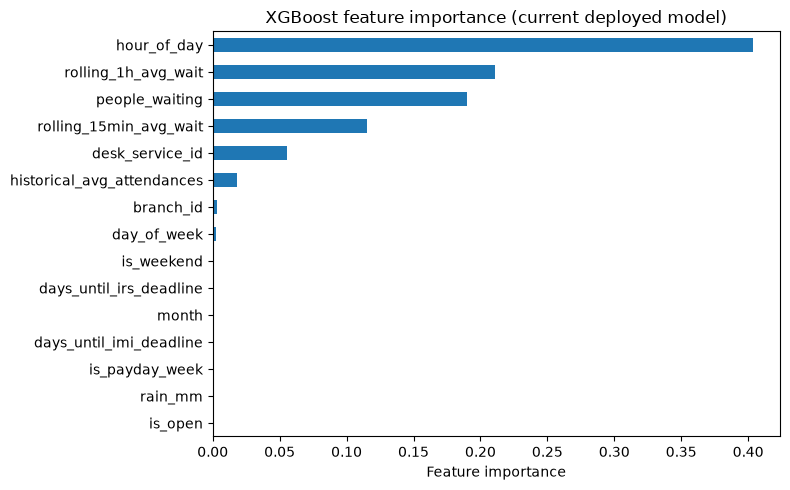

hour_of_day                   0.403598
rolling_1h_avg_wait           0.210962
people_waiting                0.190286
rolling_15min_avg_wait        0.115314
desk_service_id               0.055674
historical_avg_attendances    0.017915
branch_id                     0.003010
day_of_week                   0.002668
is_weekend                    0.000228
days_until_irs_deadline       0.000129
month                         0.000108
days_until_imi_deadline       0.000058
is_payday_week                0.000049
rain_mm                       0.000000
is_open                       0.000000
dtype: float32

In [6]:
importances = pd.Series(model.feature_importances_, index=artifact["feature_columns"]).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_xlabel("Feature importance")
ax.set_title("XGBoost feature importance (current deployed model)")
plt.tight_layout()
plt.show()
importances

## 4. The R² diagnostic — why the blended number is misleading

Retrains fresh (chronological split, same as `pipeline/train.py`) and reports
metrics two ways: blended across all sources, and segmented by source. If
`historical_derived_proxy` rows dominate the row count, the blended R² will
look near-perfect almost regardless of real-world accuracy — that's
curve-fitting a known formula, not evidence of predictive skill. The
`siga_live` row shows what real measured data actually supports right now.

In [7]:
frame = load_training_frame(DEFAULT_DB_PATH)
print(f"Loaded {len(frame)} labeled rows spanning {frame['sampled_at'].min()} to {frame['sampled_at'].max()}")

transformer = QueueFeatureTransformer()
features = transformer.transform(frame)
features[TARGET_COLUMN] = frame[TARGET_COLUMN]
features["sampled_at"] = frame["sampled_at"]
features["source"] = frame["source"]
features = features.sort_values("sampled_at").reset_index(drop=True)

train_frame, test_frame = chronological_split(features, test_fraction=0.2)
X_train, y_train = train_frame[FEATURE_COLUMNS], train_frame[TARGET_COLUMN]
X_test, y_test = test_frame[FEATURE_COLUMNS], test_frame[TARGET_COLUMN]

weights = compute_sample_weights(train_frame)
live_in_train = int((train_frame["source"] == "siga_live").sum())
print(f"Live (siga_live) rows in this training split: {live_in_train}")

fresh_model = train_model(X_train, y_train, sample_weight=weights)
blended_metrics = evaluate(fresh_model, X_test, y_test)
by_source = evaluate_by_source(fresh_model, test_frame, FEATURE_COLUMNS, TARGET_COLUMN)

print()
print("Blended metrics:", blended_metrics)
print()
print("By source:")
for source, m in by_source.items():
    print(f"  {source}: {m}")

Loaded 1705259 labeled rows spanning 2024-08-01 09:30:00+00:00 to 2026-07-27 11:16:38.914503+00:00


Weather fetch failed for (40.4426833, -8.4359581) [2024-08-01..2026-07-27]; falling back to baseline
Traceback (most recent call last):
  File "/Users/migueltomasdapontegomes/Documents/GitHub/ods/loja-cidadao/.venv/lib/python3.13/site-packages/openmeteo_requests/Client.py", line 88, in weather_api
    return self._request(
           ~~~~~~~~~~~~~^
        url=url,
        ^^^^^^^^
    ...<3 lines>...
        **kwargs,
        ^^^^^^^^^
    )
    ^
  File "/Users/migueltomasdapontegomes/Documents/GitHub/ods/loja-cidadao/.venv/lib/python3.13/site-packages/openmeteo_requests/Client.py", line 72, in _request
    raise OpenMeteoRequestsError(response_body)
openmeteo_requests.Client.OpenMeteoRequestsError: {'error': True, 'reason': "Parameter 'start_date' is out of allowed range from 2026-04-25 to 2026-08-11"}

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/Users/migueltomasdapontegomes/Documents/GitHub/ods/loja-cidadao/pipe

Weather fetch failed for (39.6578998, -8.8243713) [2024-08-01..2026-07-27]; falling back to baseline
Traceback (most recent call last):
  File "/Users/migueltomasdapontegomes/Documents/GitHub/ods/loja-cidadao/.venv/lib/python3.13/site-packages/openmeteo_requests/Client.py", line 88, in weather_api
    return self._request(
           ~~~~~~~~~~~~~^
        url=url,
        ^^^^^^^^
    ...<3 lines>...
        **kwargs,
        ^^^^^^^^^
    )
    ^
  File "/Users/migueltomasdapontegomes/Documents/GitHub/ods/loja-cidadao/.venv/lib/python3.13/site-packages/openmeteo_requests/Client.py", line 72, in _request
    raise OpenMeteoRequestsError(response_body)
openmeteo_requests.Client.OpenMeteoRequestsError: {'reason': "Parameter 'start_date' is out of allowed range from 2026-04-25 to 2026-08-11", 'error': True}

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/Users/migueltomasdapontegomes/Documents/GitHub/ods/loja-cidadao/pipe

Weather fetch failed for (40.5378408, -7.2662964) [2024-08-01..2026-07-27]; falling back to baseline
Traceback (most recent call last):
  File "/Users/migueltomasdapontegomes/Documents/GitHub/ods/loja-cidadao/.venv/lib/python3.13/site-packages/openmeteo_requests/Client.py", line 88, in weather_api
    return self._request(
           ~~~~~~~~~~~~~^
        url=url,
        ^^^^^^^^
    ...<3 lines>...
        **kwargs,
        ^^^^^^^^^
    )
    ^
  File "/Users/migueltomasdapontegomes/Documents/GitHub/ods/loja-cidadao/.venv/lib/python3.13/site-packages/openmeteo_requests/Client.py", line 72, in _request
    raise OpenMeteoRequestsError(response_body)
openmeteo_requests.Client.OpenMeteoRequestsError: {'reason': "Parameter 'start_date' is out of allowed range from 2026-04-25 to 2026-08-11", 'error': True}

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/Users/migueltomasdapontegomes/Documents/GitHub/ods/loja-cidadao/pipe

Weather fetch failed for (38.7077507, -9.1365919) [2024-08-01..2026-07-27]; falling back to baseline
Traceback (most recent call last):
  File "/Users/migueltomasdapontegomes/Documents/GitHub/ods/loja-cidadao/.venv/lib/python3.13/site-packages/openmeteo_requests/Client.py", line 88, in weather_api
    return self._request(
           ~~~~~~~~~~~~~^
        url=url,
        ^^^^^^^^
    ...<3 lines>...
        **kwargs,
        ^^^^^^^^^
    )
    ^
  File "/Users/migueltomasdapontegomes/Documents/GitHub/ods/loja-cidadao/.venv/lib/python3.13/site-packages/openmeteo_requests/Client.py", line 72, in _request
    raise OpenMeteoRequestsError(response_body)
openmeteo_requests.Client.OpenMeteoRequestsError: {'reason': "Parameter 'start_date' is out of allowed range from 2026-04-25 to 2026-08-11", 'error': True}

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/Users/migueltomasdapontegomes/Documents/GitHub/ods/loja-cidadao/pipe

...

Weather fetch failed for (39.53347, -8.16034) [2024-08-01..2026-07-27]; falling back to baseline
Traceback (most recent call last):
  File "/Users/migueltomasdapontegomes/Documents/GitHub/ods/loja-cidadao/.venv/lib/python3.13/site-packages/openmeteo_requests/Client.py", line 88, in weather_api
    return self._request(
           ~~~~~~~~~~~~~^
        url=url,
        ^^^^^^^^
    ...<3 lines>...
        **kwargs,
        ^^^^^^^^^
    )
    ^
  File "/Users/migueltomasdapontegomes/Documents/GitHub/ods/loja-cidadao/.venv/lib/python3.13/site-packages/openmeteo_requests/Client.py", line 72, in _request
    raise OpenMeteoRequestsError(response_body)
openmeteo_requests.Client.OpenMeteoRequestsError: {'error': True, 'reason': "Parameter 'start_date' is out of allowed range from 2026-04-25 to 2026-08-11"}

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/Users/migueltomasdapontegomes/Documents/GitHub/ods/loja-cidadao/pipeline

Weather fetch failed for (38.6422246, -9.1072662) [2024-08-01..2026-07-27]; falling back to baseline
Traceback (most recent call last):
  File "/Users/migueltomasdapontegomes/Documents/GitHub/ods/loja-cidadao/.venv/lib/python3.13/site-packages/openmeteo_requests/Client.py", line 88, in weather_api
    return self._request(
           ~~~~~~~~~~~~~^
        url=url,
        ^^^^^^^^
    ...<3 lines>...
        **kwargs,
        ^^^^^^^^^
    )
    ^
  File "/Users/migueltomasdapontegomes/Documents/GitHub/ods/loja-cidadao/.venv/lib/python3.13/site-packages/openmeteo_requests/Client.py", line 72, in _request
    raise OpenMeteoRequestsError(response_body)
openmeteo_requests.Client.OpenMeteoRequestsError: {'error': True, 'reason': "Parameter 'start_date' is out of allowed range from 2026-04-25 to 2026-08-11"}

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/Users/migueltomasdapontegomes/Documents/GitHub/ods/loja-cidadao/pipe

Weather fetch failed for (41.5849534, -6.5291002) [2024-08-01..2026-07-27]; falling back to baseline
Traceback (most recent call last):
  File "/Users/migueltomasdapontegomes/Documents/GitHub/ods/loja-cidadao/.venv/lib/python3.13/site-packages/openmeteo_requests/Client.py", line 88, in weather_api
    return self._request(
           ~~~~~~~~~~~~~^
        url=url,
        ^^^^^^^^
    ...<3 lines>...
        **kwargs,
        ^^^^^^^^^
    )
    ^
  File "/Users/migueltomasdapontegomes/Documents/GitHub/ods/loja-cidadao/.venv/lib/python3.13/site-packages/openmeteo_requests/Client.py", line 72, in _request
    raise OpenMeteoRequestsError(response_body)
openmeteo_requests.Client.OpenMeteoRequestsError: {'error': True, 'reason': "Parameter 'start_date' is out of allowed range from 2026-04-25 to 2026-08-11"}

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/Users/migueltomasdapontegomes/Documents/GitHub/ods/loja-cidadao/pipe

Live (siga_live) rows in this training split: 0



Blended metrics: {'mae': 0.318555784580779, 'rmse': 6.335138448551795, 'r2': 0.8138608922362511}

By source:
  historical_derived_proxy: {'n': 339778, 'mae': 0.16510821652582583, 'rmse': 0.5058726406795401, 'r2': 0.9985555805772337, 'note': None}
  siga_live: {'n': 1274, 'mae': 41.243287164938614, 'rmse': 103.32320481765522, 'r2': -0.18387634523794283, 'note': None}


### 4b. Ablation — how much of the fit is `people_waiting` alone doing?

Drops the single most important feature and re-evaluates. If R² barely
moves, it confirms multiple redundant features (not just one) let the model
reconstruct the formula-derived label — evidence this is curve-fitting, not
generalization.

In [8]:
ablated_cols = [c for c in FEATURE_COLUMNS if c != "people_waiting"]
ablated_model = train_model(train_frame[ablated_cols], y_train)
ablated_metrics = evaluate(ablated_model, test_frame[ablated_cols], y_test)

print("Full feature set:      ", blended_metrics)
print("Without people_waiting:", ablated_metrics)

Full feature set:       {'mae': 0.318555784580779, 'rmse': 6.335138448551795, 'r2': 0.8138608922362511}
Without people_waiting: {'mae': 0.3787768930469242, 'rmse': 6.336588900761224, 'r2': 0.8137756480732647}


## 5. Real data coverage per (branch, service) combo

A single "N live rows total" number hides that coverage is combo-by-combo,
not global — `compute_sample_weights` decays proxy weight per-combo as real
`siga_live` coverage grows for that *specific* combo, so what matters is how
many combos have crossed a meaningful sample threshold, not the raw total.

In [9]:
coverage = build_coverage_report(DEFAULT_DB_PATH)
if coverage.empty:
    print("No real siga_live samples yet.")
else:
    MIN_SAMPLES = 30
    total_combos = len(coverage)
    meaningfully_covered = int((coverage["live_count"] >= MIN_SAMPLES).sum())
    vocab_matched = int(coverage["matches_proxy_vocabulary"].sum())

    print(f"Real (branch, service) combos observed: {total_combos}")
    print(f"Combos with >= {MIN_SAMPLES} real samples: {meaningfully_covered}")
    print(f"Combos whose SIGA name matches the dados.gov.pt vocabulary (proxy-decay applies): {vocab_matched}/{total_combos}")
    print()
    display(coverage.sort_values("live_count", ascending=False).head(20))

Real (branch, service) combos observed: 1790
Combos with >= 30 real samples: 0
Combos whose SIGA name matches the dados.gov.pt vocabulary (proxy-decay applies): 1560/1790



,branch_id,desk_service_id,live_count,first_seen,last_seen,proxy_weight,matches_proxy_vocabulary
0,loja_de_cidadao_da_anadia,Acolhimento,5,2026-07-26 23:34:46.048292+00:00,2026-07-27 11:16:38.914503+00:00,0.8,True
1189,loja_de_cidadao_da_anadia,Nacionalidade - Profissionais,5,2026-07-26 23:34:46.048292+00:00,2026-07-27 11:16:38.914503+00:00,0.8,True
1200,loja_de_cidadao_da_anadia,Cartão de Cidadão - Levantamento,5,2026-07-26 23:34:46.048292+00:00,2026-07-27 11:16:38.914503+00:00,0.8,True
1199,loja_de_cidadao_da_anadia,Cartão de Cidadão - Outros,5,2026-07-26 23:34:46.048292+00:00,2026-07-27 11:16:38.914503+00:00,0.8,True
1198,loja_de_cidadao_da_anadia,Cartão de Cidadão - Pedido/Renovação,5,2026-07-26 23:34:46.048292+00:00,2026-07-27 11:16:38.914503+00:00,0.8,True
1197,loja_de_cidadao_da_anadia,Casa Pronta,5,2026-07-26 23:34:46.048292+00:00,2026-07-27 11:16:38.914503+00:00,0.8,True
1196,loja_de_cidadao_da_anadia,Empresa na Hora / Marca / Associação / Coopera...,5,2026-07-26 23:34:46.048292+00:00,2026-07-27 11:16:38.914503+00:00,0.8,True
1195,loja_de_cidadao_da_anadia,Entrega de Documentos,5,2026-07-26 23:34:46.048292+00:00,2026-07-27 11:16:38.914503+00:00,0.8,True
1194,loja_de_cidadao_da_anadia,Execuções Fiscais,5,2026-07-26 23:34:46.048292+00:00,2026-07-27 11:16:38.914503+00:00,0.8,True
1193,loja_de_cidadao_da_anadia,Geral,5,2026-07-26 23:34:46.048292+00:00,2026-07-27 11:16:38.914503+00:00,0.8,False


## 6. Real vs. raw wait-time filtering

Real `tempoRealEspera` readings are sometimes wildly implausible (found
2026-07-27: readings uncorrelated with actual queue size, some in the
thousands of minutes). `raw_wait_time_minutes` always keeps the untouched
value; `wait_time_minutes` is the filtered one everything else reads. This
cell shows how much filtering is currently happening, live, on whatever data
exists right now.

In [10]:
live = pd.read_sql_query('''
    SELECT branch_id, desk_service_id, sampled_at, people_waiting, wait_time_minutes, raw_wait_time_minutes
    FROM queue_samples WHERE source = 'siga_live' AND raw_wait_time_minutes IS NOT NULL
''', conn)

if live.empty:
    print("No real siga_live readings with a raw wait time yet.")
else:
    implausible = live[live["raw_wait_time_minutes"] > REAL_DATA_MAX_PLAUSIBLE_WAIT_MINUTES]
    print(f"Real readings with a raw wait time: {len(live)}")
    print(f"Filtered out as implausible (> {REAL_DATA_MAX_PLAUSIBLE_WAIT_MINUTES} min): {len(implausible)} ({len(implausible)/len(live)*100:.1f}%)")
    print()
    print("Sample of filtered (implausible) readings -- note people_waiting is often low/zero despite a huge raw wait:")
    display(implausible.sort_values("raw_wait_time_minutes", ascending=False).head(10))

Real readings with a raw wait time: 1866
Filtered out as implausible (> 480 min): 592 (31.7%)

Sample of filtered (implausible) readings -- note people_waiting is often low/zero despite a huge raw wait:


,branch_id,desk_service_id,sampled_at,people_waiting,wait_time_minutes,raw_wait_time_minutes
1456,loja_de_cidadao_do_seixal,Atendimento Geral,2026-07-27T11:16:38.914503+00:00,124,NaN,13366.0
312,loja_de_cidadao_de_odivelas,Atendimento Geral,2026-07-27T11:16:38.914503+00:00,0,NaN,13233.0
1504,loja_de_cidadao_do_seixal,Posto de serviços rápidos,2026-07-27T11:16:38.914503+00:00,12,NaN,12707.0
1158,loja_de_cidadao_de_faro,Cartão de Cidadão - Pedido/Renovação,2026-07-27T11:16:38.914503+00:00,27,NaN,12700.0
368,loja_de_cidadao_do_cacem,CLAIM,2026-07-27T11:16:38.914503+00:00,7,NaN,12479.0
446,loja_de_cidadao_do_saldanha,Condutores,2026-07-27T11:16:38.914503+00:00,30,NaN,12438.0
1702,loja_de_cidadao_de_ribeira_de_pena,Registo veículos - Pedido,2026-07-27T11:16:38.914503+00:00,0,NaN,12418.0
477,loja_de_cidadao_de_marvila,Posto de serviços rápidos,2026-07-27T11:16:38.914503+00:00,25,NaN,12401.0
1135,loja_de_cidadao_de_faro,Atendimento Geral,2026-07-27T11:16:38.914503+00:00,0,NaN,12324.0
449,loja_de_cidadao_do_saldanha,Transportes,2026-07-27T11:16:38.914503+00:00,0,NaN,12319.0


## 7. Live snapshot for one branch

Change `branch_id` below to inspect a different branch (see `BRANCHES` from
`config.py` for the full list of valid ids).

In [11]:
branch_id = "loja_de_cidadao_das_laranjeiras"  # change this to inspect a different branch

snapshot = pd.read_sql_query(f'''
    SELECT sampled_at, desk_service_id, is_open, people_waiting, wait_time_minutes, raw_wait_time_minutes
    FROM queue_samples
    WHERE source='siga_live' AND branch_id='{branch_id}'
    ORDER BY sampled_at DESC
    LIMIT 50
''', conn)
print(f"Most recent real readings for {branch_id}:")
display(snapshot)

Most recent real readings for loja_de_cidadao_das_laranjeiras:


,sampled_at,desk_service_id,is_open,people_waiting,wait_time_minutes,raw_wait_time_minutes
0,2026-07-27T11:16:38.914503+00:00,Aplicações Financeiras,1,0.0,NaN,1529.0
1,2026-07-27T11:16:38.914503+00:00,Atendimento Empresarial,1,0.0,0.0,0.0
2,2026-07-27T11:16:38.914503+00:00,Atendimento Geral,1,120.0,NaN,8315.0
3,2026-07-27T11:16:38.914503+00:00,Atendimento Geral/ General Attendance,1,64.0,NaN,9209.0
4,2026-07-27T11:16:38.914503+00:00,Atendimento com Marcação,0,NaN,NaN,NaN
5,2026-07-27T11:16:38.914503+00:00,Atendimento geral; Declarações; Atualizações,1,0.0,274.0,274.0
6,2026-07-27T11:16:38.914503+00:00,Carta de Condução/ Driving License,1,6.0,NaN,3390.0
7,2026-07-27T11:16:38.914503+00:00,Cartão de Cidadão - Levantamento,1,3.0,NaN,539.0
8,2026-07-27T11:16:38.914503+00:00,Cartão de Cidadão - Outros,1,0.0,NaN,9265.0
9,2026-07-27T11:16:38.914503+00:00,Cartão de Cidadão - Pedido/Renovação,1,15.0,NaN,11871.0


## Summary

- Blended R² is dominated by proxy-derived data and should not be read as
  real-world predictive accuracy — always check the per-source breakdown
  (section 4) instead.
- Real coverage is combo-specific (section 5) — track progress there, not a
  single aggregate row count.
- A meaningful chunk of real wait-time readings are implausible at the
  source (section 6) and are correctly excluded from training rather than
  silently trusted.
- Re-run this notebook periodically (e.g. weekly) to watch these numbers
  evolve as more real data accumulates.